#Data Cleaning Operation

In [32]:
#importing the libraries

import pandas as pd
import numpy as np


#if the visualization is needed for that file for the testing 

import matplotlib.pyplot as plt


In [33]:
#thus starting with the reading of the file in the given data folder
#thus we copy the relative path of teh image so that it becomes easier

df=pd.read_csv('../data/imdb-top-1000.csv')

df

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166544,679874270.0,76.0
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34075,195217415.0,84.0
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43374,30500000.0,85.0
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852142728.0,78.0


In [34]:
#the shape of the given data is

#so in the given data there are 1000 number of the rows and the number of the columns is 10

df.shape

(1000, 10)

In [35]:
#now checking the dtypes of all the columns in the given dataset

df.dtypes

#so here i can see that the dtypes of all the data is correct and per the sequence 
#but the data in the released year is in the form of the string not in the form of the number 



Series_Title         str
Released_Year        str
Runtime            int64
Genre                str
IMDB_Rating      float64
Director             str
Star1                str
No_of_Votes        int64
Gross            float64
Metascore        float64
dtype: object

#Handling the Missing Values

In [36]:
df.isnull().sum()

Series_Title       0
Released_Year      0
Runtime            0
Genre              0
IMDB_Rating        0
Director           0
Star1              0
No_of_Votes        0
Gross              0
Metascore        157
dtype: int64

In [37]:
#handling the missing values in the data

df.isnull().sum()

#thus the metascore contains the 157 missing values 

df[df['Metascore'].isnull()]

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
20,Soorarai Pottru,2020,153,Drama,8.6,Sudha Kongara,Suriya,54995,556832648.0,NaN
54,Ayla: The Daughter of War,2017,125,Biography,8.4,Can Ulkay,Erdem Can,34112,679278040.0,NaN
55,Vikram Vedha,2017,147,Action,8.4,Gayatri,Pushkar,28401,357599391.0,NaN
57,Dangal,2016,161,Action,8.4,Nitesh Tiwari,Aamir Khan,156479,12391761.0,NaN
65,Taare Zameen Par,2007,165,Drama,8.4,Aamir Khan,Amole Gupte,168895,1223869.0,NaN
...,...,...,...,...,...,...,...,...,...,...
872,The Day the Earth Stood Still,1951,92,Drama,7.7,Robert Wise,Michael Rennie,76315,895071115.0,NaN
874,Gilda,1946,110,Drama,7.7,Charles Vidor,Rita Hayworth,27991,532234536.0,NaN
899,El cuerpo,2012,112,Mystery,7.6,Oriol Paulo,Jose Coronado,57549,140340673.0,NaN
909,Celda 211,2009,113,Action,7.6,Daniel Monzón,Luis Tosar,63882,242105549.0,NaN


In [38]:
(df.describe().round()/len(df))*100

#so the number of the data is less than the 50 percent so we have to apply the imputation in the column

,Runtime,IMDB_Rating,No_of_Votes,Gross,Metascore
count,100.0,100.0,100.0,100.0,84.3
mean,12.3,0.8,27369.3,12827807.5,7.8
std,2.8,0.0,32737.3,20111100.9,1.2
min,4.5,0.8,2508.8,130.5,2.8
25%,10.3,0.8,5552.6,501291.9,7.0
50%,11.9,0.8,13854.8,3953432.1,7.9
75%,13.7,0.8,37416.1,16159969.7,8.7
max,32.1,0.9,234311.0,93666222.5,10.0


In [39]:
df['Metascore'].mean()

#in the given data set we see that the given dataset have the less difference between the mean and the median so that mean=77 and the median of the data=79

#so we are going to fill the data containing the NaN with the median because they dont follow the pattern of the data

np.float64(77.97153024911032)

In [40]:
df[df['Metascore'].isnull()]

#thus filling the data with the median 
#20 54 55 57 65 


df['Metascore']=df['Metascore'].fillna(df['Metascore'].median())
df.loc[15:70]



,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
15,Goodfellas,1990,146,Biography,8.7,Martin Scorsese,Robert De Niro,1020727,46836394.0,90.0
16,Star Wars: Episode V - The Empire Strikes Back,1980,124,Action,8.7,Irvin Kershner,Mark Hamill,1159315,290475067.0,82.0
17,One Flew Over the Cuckoo's Nest,1975,133,Drama,8.7,Milos Forman,Jack Nicholson,918088,112000000.0,83.0
18,Hamilton,2020,160,Biography,8.6,Thomas Kail,Lin-Manuel Miranda,55291,440984783.0,90.0
19,Gisaengchung,2019,132,Comedy,8.6,Bong Joon Ho,Kang-ho Song,552778,53367844.0,96.0
20,Soorarai Pottru,2020,153,Drama,8.6,Sudha Kongara,Suriya,54995,556832648.0,79.0
21,Interstellar,2014,169,Adventure,8.6,Christopher Nolan,Matthew McConaughey,1512360,188020017.0,74.0
22,Cidade de Deus,2002,130,Crime,8.6,Fernando Meirelles,Kátia Lund,699256,7563397.0,79.0
23,Sen to Chihiro no kamikakushi,2001,125,Animation,8.6,Hayao Miyazaki,Daveigh Chase,651376,10055859.0,96.0
24,Saving Private Ryan,1998,169,Drama,8.6,Steven Spielberg,Tom Hanks,1235804,216540909.0,91.0


<Axes: >

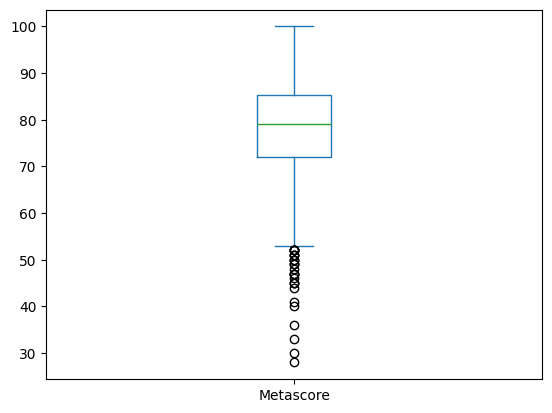

In [41]:


#so here we remove all the missing values in the data of the metascore


df['Metascore'].plot(kind='box')

In [42]:
#checking the missing value in the whole data
df.isnull().sum()

#hence the first part of the checking the null values is already handled 

Series_Title     0
Released_Year    0
Runtime          0
Genre            0
IMDB_Rating      0
Director         0
Star1            0
No_of_Votes      0
Gross            0
Metascore        0
dtype: int64

##Checking the Duplicate data


In [43]:
df.duplicated().sum()

#checking the duplicate data hence it does not contain the duplicated data in the dataset
df[df.duplicated()]

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore


In [44]:
#Handling the incorrect data types 

df.shape

#total there are 1000 values so thus each column contains the same number of the values if the type is same

df['Released_Year'].value_counts()

Released_Year
2014    32
2004    31
2009    29
2016    28
2013    28
        ..
1920     1
1930     1
1922     1
1943     1
PG       1
Name: count, Length: 100, dtype: int64

In [45]:
for col in df.columns:
    if df[col].nunique()<1000:
        print(df[col].value_counts())
        print('-'*50)

#it is used to check the number of the unique values in the whole data

Series_Title
Drishyam                    2
The Shawshank Redemption    1
The Godfather               1
The Dark Knight             1
The Godfather: Part II      1
                           ..
Breakfast at Tiffany's      1
Giant                       1
From Here to Eternity       1
Lifeboat                    1
The 39 Steps                1
Name: count, Length: 999, dtype: int64
--------------------------------------------------
Released_Year
2014    32
2004    31
2009    29
2016    28
2013    28
        ..
1920     1
1930     1
1922     1
1943     1
PG       1
Name: count, Length: 100, dtype: int64
--------------------------------------------------
Runtime
130    23
100    23
101    22
113    22
129    22
       ..
69      1
70      1
242     1
79      1
78      1
Name: count, Length: 140, dtype: int64
--------------------------------------------------
Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery  

In [46]:
#so here in the given data the value Released year is used to contain the str but the released year should be in the number format

df.dtypes

Series_Title         str
Released_Year        str
Runtime            int64
Genre                str
IMDB_Rating      float64
Director             str
Star1                str
No_of_Votes        int64
Gross            float64
Metascore        float64
dtype: object

In [47]:
df['Released_Year']=pd.to_numeric(df['Released_Year'],errors='coerce')
df.dtypes


Series_Title         str
Released_Year    float64
Runtime            int64
Genre                str
IMDB_Rating      float64
Director             str
Star1                str
No_of_Votes        int64
Gross            float64
Metascore        float64
dtype: object

In [48]:
#now checking the null values in the released year
df[df['Released_Year'].isnull()]

df['Released_Year']=df['Released_Year'].fillna(df['Released_Year'].median())

#changing the dtypes of the float 64 to the int64 in the Released_Year
df['Released_Year']=df['Released_Year'].astype('int64')
df




,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80.0
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100.0
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84.0
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90.0
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96.0
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166544,679874270.0,76.0
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34075,195217415.0,84.0
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43374,30500000.0,85.0
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852142728.0,78.0


In [49]:
df.dtypes


Series_Title         str
Released_Year      int64
Runtime            int64
Genre                str
IMDB_Rating      float64
Director             str
Star1                str
No_of_Votes        int64
Gross            float64
Metascore        float64
dtype: object

In [50]:
df[df['Genre'].str.contains('Drama')].sample(50)
df['Genre'].value_counts()

Genre
Drama        289
Action       172
Comedy       155
Crime        107
Biography     88
Animation     82
Adventure     72
Mystery       12
Horror        11
Western        4
Film-Noir      3
Fantasy        2
Family         2
Thriller       1
Name: count, dtype: int64

In [51]:
df.sample(50)

#lets change the metascore to the int 64

df['Metascore']=df['Metascore'].astype('int64')
df



,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28341469.0,80
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134966411.0,100
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534858444.0,84
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57300000.0,90
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4360000.0,96
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166544,679874270.0,76
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34075,195217415.0,84
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43374,30500000.0,85
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852142728.0,78


In [52]:
#To convert the Gross amount to the millions form
df['Gross']=(df['Gross']/1000000).round(2)

#now if i want to add the Million option in it i need to convert the data type



In [53]:

df

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343110,28.34,80
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620367,134.97,100
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303232,534.86,84
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129952,57.30,90
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689845,4.36,96
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166544,679.87,76
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34075,195.22,84
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43374,30.50,85
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26471,852.14,78


In [54]:
#same with the no of votes

df['No_of_Votes']=(df['No_of_Votes']/1000).round(3)

In [55]:
df

,Series_Title,Released_Year,Runtime,Genre,IMDB_Rating,Director,Star1,No_of_Votes,Gross,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343.110,28.34,80
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620.367,134.97,100
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303.232,534.86,84
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129.952,57.30,90
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689.845,4.36,96
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166.544,679.87,76
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34.075,195.22,84
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43.374,30.50,85
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26.471,852.14,78


In [56]:
#thus i need to change the name of the columns 

df.rename(columns={
    'Series_Title':'Name',
    'Released_Year':'Year',
    'Runtime':'Duration',
    'Genre':'Genres',
    'IMDB_Rating':'IMDB',
    'Star1':'Lead',
    'No_of_Votes':'Votes_per_K',
    'Gross':'Gross_per_M'
    
},inplace=True)

df

,Name,Year,Duration,Genres,IMDB,Director,Lead,Votes_per_K,Gross_per_M,Metascore
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343.110,28.34,80
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620.367,134.97,100
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303.232,534.86,84
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129.952,57.30,90
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689.845,4.36,96
...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166.544,679.87,76
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34.075,195.22,84
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43.374,30.50,85
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26.471,852.14,78


In [57]:
#apply the decade scetion in the decade for the imdb rating

df['Decade']=(df['Year']//10)*10

In [58]:
df

,Name,Year,Duration,Genres,IMDB,Director,Lead,Votes_per_K,Gross_per_M,Metascore,Decade
0,The Shawshank Redemption,1994,142,Drama,9.3,Frank Darabont,Tim Robbins,2343.110,28.34,80,1990
1,The Godfather,1972,175,Crime,9.2,Francis Ford Coppola,Marlon Brando,1620.367,134.97,100,1970
2,The Dark Knight,2008,152,Action,9.0,Christopher Nolan,Christian Bale,2303.232,534.86,84,2000
3,The Godfather: Part II,1974,202,Crime,9.0,Francis Ford Coppola,Al Pacino,1129.952,57.30,90,1970
4,12 Angry Men,1957,96,Crime,9.0,Sidney Lumet,Henry Fonda,689.845,4.36,96,1950
...,...,...,...,...,...,...,...,...,...,...,...
995,Breakfast at Tiffany's,1961,115,Comedy,7.6,Blake Edwards,Audrey Hepburn,166.544,679.87,76,1960
996,Giant,1956,201,Drama,7.6,George Stevens,Elizabeth Taylor,34.075,195.22,84,1950
997,From Here to Eternity,1953,118,Drama,7.6,Fred Zinnemann,Burt Lancaster,43.374,30.50,85,1950
998,Lifeboat,1944,97,Drama,7.6,Alfred Hitchcock,Tallulah Bankhead,26.471,852.14,78,1940


In [59]:
df.isnull().sum()

Name           0
Year           0
Duration       0
Genres         0
IMDB           0
Director       0
Lead           0
Votes_per_K    0
Gross_per_M    0
Metascore      0
Decade         0
dtype: int64

In [60]:
df.duplicated().sum()

np.int64(0)

In [61]:
#so just make the new file for it in the form of the imdb_cleaned csv

df.to_csv('../data/imdb-cleaned.csv',index=False)
